# Step 7: Model Comparison & Recommendation

This notebook compares all three trained models, resolves all pending issues from Steps 1-6, and delivers a final model recommendation.

## Models Compared
| Step | Model | Type |
|---|---|---|
| Step 4 | Logistic Regression | Linear baseline |
| Step 5 | Decision Tree | Single non-linear tree |
| Step 6 | LightGBM | Gradient boosting ensemble |

## Roadmap
1. Load all results and models
2. Side-by-side metrics comparison
3. ROC, PR, and calibration curves -- all three models overlaid
4. Feature importance comparison
5. Cost-benefit analysis
6. Pending issues resolution
7. Final model recommendation


## 0. Imports & Configuration

In [1]:
import os, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, brier_score_loss
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

ARTEFACT_DIR = '../prepared_data'
MODEL_DIR    = '../models'

COLORS = {
    'Logistic Regression': '#4C72B0',
    'Decision Tree'      : '#55A868',
    'LightGBM'           : '#DD8452',
}

print(f'ARTEFACT_DIR : {os.path.abspath(ARTEFACT_DIR)}')
print(f'MODEL_DIR    : {os.path.abspath(MODEL_DIR)}')


ARTEFACT_DIR : /Users/martinmilon/Documents/DTSC870/prepared_data
MODEL_DIR    : /Users/martinmilon/Documents/DTSC870/models


## 1. Load All Results & Models

In [2]:
lr_results  = pd.read_csv(os.path.join(MODEL_DIR, 'lr_results.csv'))
dt_results  = pd.read_csv(os.path.join(MODEL_DIR, 'dt_results.csv'))
lgb_results = pd.read_csv(os.path.join(MODEL_DIR, 'lgb_results.csv'))

lr_model  = joblib.load(os.path.join(MODEL_DIR, 'lr_tuned.pkl'))
dt_model  = joblib.load(os.path.join(MODEL_DIR, 'dt_best.pkl'))
lgb_model = joblib.load(os.path.join(MODEL_DIR, 'lgb_tuned.pkl'))

lr_coef_df = joblib.load(os.path.join(MODEL_DIR, 'lr_coef_df.pkl'))
dt_imp_df  = joblib.load(os.path.join(MODEL_DIR, 'dt_importance.pkl'))
lgb_imp_df = joblib.load(os.path.join(MODEL_DIR, 'lgb_importance.pkl'))

FEATURE_COLS    = joblib.load(os.path.join(ARTEFACT_DIR, 'feature_cols.pkl'))
FEATURE_COLS_LR = [c for c in FEATURE_COLS if c != 'aisle_id']
FEATURE_COLS_DT = [c for c in FEATURE_COLS
                   if c not in ['aisle_id', 'up_avg_add_to_cart', 'up_orders_since_last']]

X_test_scaled = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'X_test_scaled.parquet'))
X_test_raw    = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'X_test.parquet'))
y_test        = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'y_test.parquet'))['reordered']

X_test_lgb = X_test_raw[FEATURE_COLS].copy()
for col in ['aisle_id', 'department_id']:
    X_test_lgb[col] = X_test_lgb[col].astype('category')

y_prob_lr  = lr_model.predict_proba(X_test_scaled[FEATURE_COLS_LR])[:, 1]
y_prob_dt  = dt_model.predict_proba(X_test_scaled[FEATURE_COLS_DT])[:, 1]
y_prob_lgb = lgb_model.predict_proba(X_test_lgb)[:, 1]

print('All models and artefacts loaded successfully.')
print(f'Test set size : {len(y_test):,} rows')


All models and artefacts loaded successfully.
Test set size : 277,201 rows


## 2. Side-by-Side Metrics Comparison

### 2.1 Consolidated Metrics Table


In [3]:
metrics = ['ROC-AUC', 'PR-AUC (Avg Prec)', 'Brier Score',
           'F1 (optimal thresh)', 'Precision (opt)', 'Recall (opt)', 'Accuracy (opt)']

comparison = pd.DataFrame({
    'Metric'             : metrics,
    'Logistic Regression': [float(lr_results[m].values[0])  for m in metrics],
    'Decision Tree'      : [float(dt_results[m].values[0])  for m in metrics],
    'LightGBM'           : [float(lgb_results[m].values[0]) for m in metrics],
})

def winner(row):
    vals = {
        'Logistic Regression': row['Logistic Regression'],
        'Decision Tree'      : row['Decision Tree'],
        'LightGBM'           : row['LightGBM'],
    }
    if row['Metric'] == 'Brier Score':
        return min(vals, key=vals.get) + ' (lower=better)'
    return max(vals, key=vals.get)

comparison['Winner'] = comparison.apply(winner, axis=1)
print(comparison.to_string(index=False))


             Metric  Logistic Regression  Decision Tree  LightGBM                  Winner
            ROC-AUC               0.9689         0.9685    0.9710                LightGBM
  PR-AUC (Avg Prec)               0.9841         0.9834    0.9851                LightGBM
        Brier Score               0.0472         0.0466    0.0458 LightGBM (lower=better)
F1 (optimal thresh)               0.9520         0.9530    0.9533                LightGBM
    Precision (opt)               0.9999         0.9987    0.9983     Logistic Regression
       Recall (opt)               0.9085         0.9113    0.9123                LightGBM
     Accuracy (opt)               0.9452         0.9462    0.9466                LightGBM


### 2.2 Metrics Bar Chart

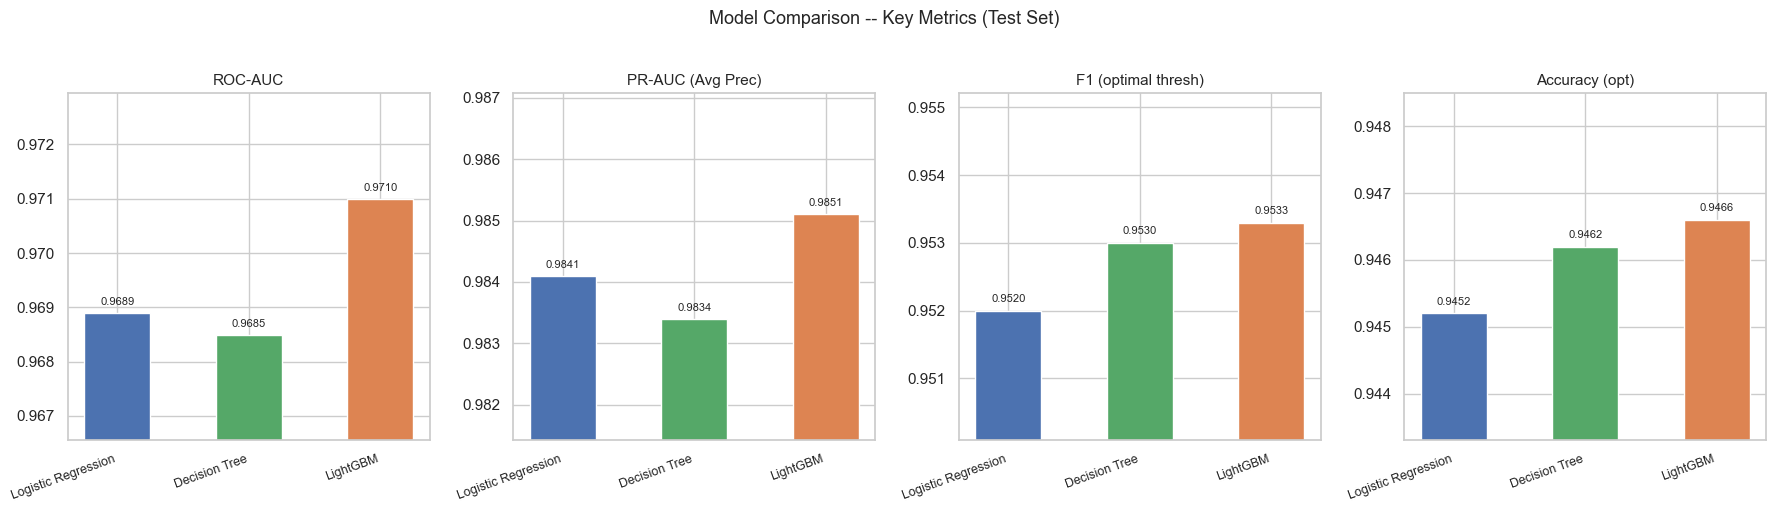

In [4]:
plot_metrics = ['ROC-AUC', 'PR-AUC (Avg Prec)', 'F1 (optimal thresh)', 'Accuracy (opt)']
models = ['Logistic Regression', 'Decision Tree', 'LightGBM']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, plot_metrics):
    vals   = [float(lr_results[metric].values[0]),
              float(dt_results[metric].values[0]),
              float(lgb_results[metric].values[0])]
    colors = [COLORS[m] for m in models]
    bars   = ax.bar(models, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(min(vals) * 0.998, max(vals) * 1.002)
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Comparison -- Key Metrics (Test Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 2.3 Brier Score Comparison (Calibration Quality)

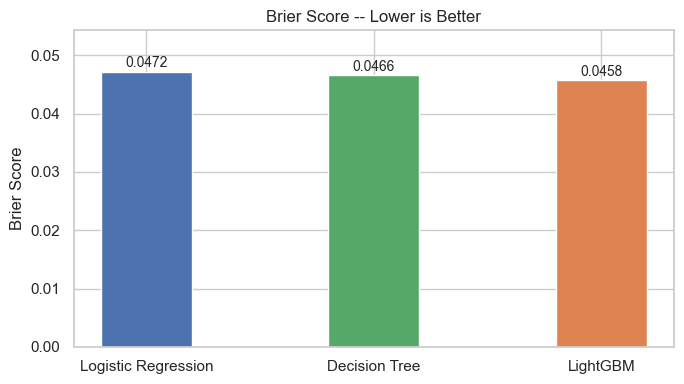

In [5]:
brier_vals = {
    'Logistic Regression': float(lr_results['Brier Score'].values[0]),
    'Decision Tree'      : float(dt_results['Brier Score'].values[0]),
    'LightGBM'           : float(lgb_results['Brier Score'].values[0]),
}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(list(brier_vals.keys()), list(brier_vals.values()),
              color=[COLORS[m] for m in brier_vals], edgecolor='white', width=0.4)
ax.set_title('Brier Score -- Lower is Better')
ax.set_ylabel('Brier Score')
ax.set_ylim(0, max(brier_vals.values()) * 1.15)
for bar, val in zip(bars, brier_vals.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


## 3. Curves -- All Three Models Overlaid

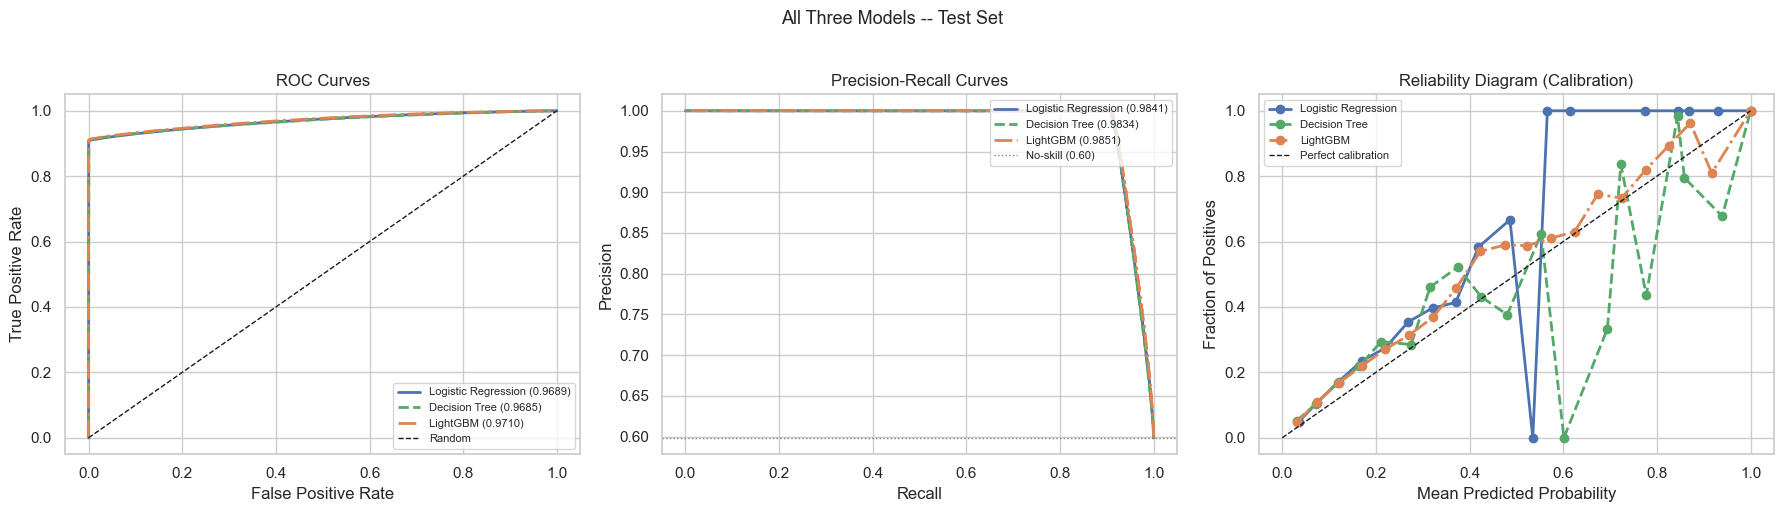

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

probs  = [y_prob_lr, y_prob_dt, y_prob_lgb]
names  = ['Logistic Regression', 'Decision Tree', 'LightGBM']
styles = ['-', '--', '-.']

for prob, name, ls in zip(probs, names, styles):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, color=COLORS[name], lw=2, linestyle=ls,
                 label=f'{name} ({auc:.4f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right', fontsize=8)

baseline = y_test.mean()
for prob, name, ls in zip(probs, names, styles):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1].plot(rec, prec, color=COLORS[name], lw=2, linestyle=ls,
                 label=f'{name} ({ap:.4f})')
axes[1].axhline(baseline, linestyle=':', color='grey', lw=1,
                label=f'No-skill ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(loc='upper right', fontsize=8)

for prob, name, ls in zip(probs, names, styles):
    pt, pp = calibration_curve(y_test, prob, n_bins=20)
    axes[2].plot(pp, pt, 'o-', color=COLORS[name], lw=2, linestyle=ls, label=name)
axes[2].plot([0,1],[0,1],'k--', lw=1, label='Perfect calibration')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives')
axes[2].set_title('Reliability Diagram (Calibration)')
axes[2].legend(loc='upper left', fontsize=8)

plt.suptitle('All Three Models -- Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 4. Feature Importance Comparison

### 4.1 Top 10 Features -- Each Model

Comparing importance across models reveals which features carry **robust signal** (important across all three) versus **model-specific signal** (important in one but not others).


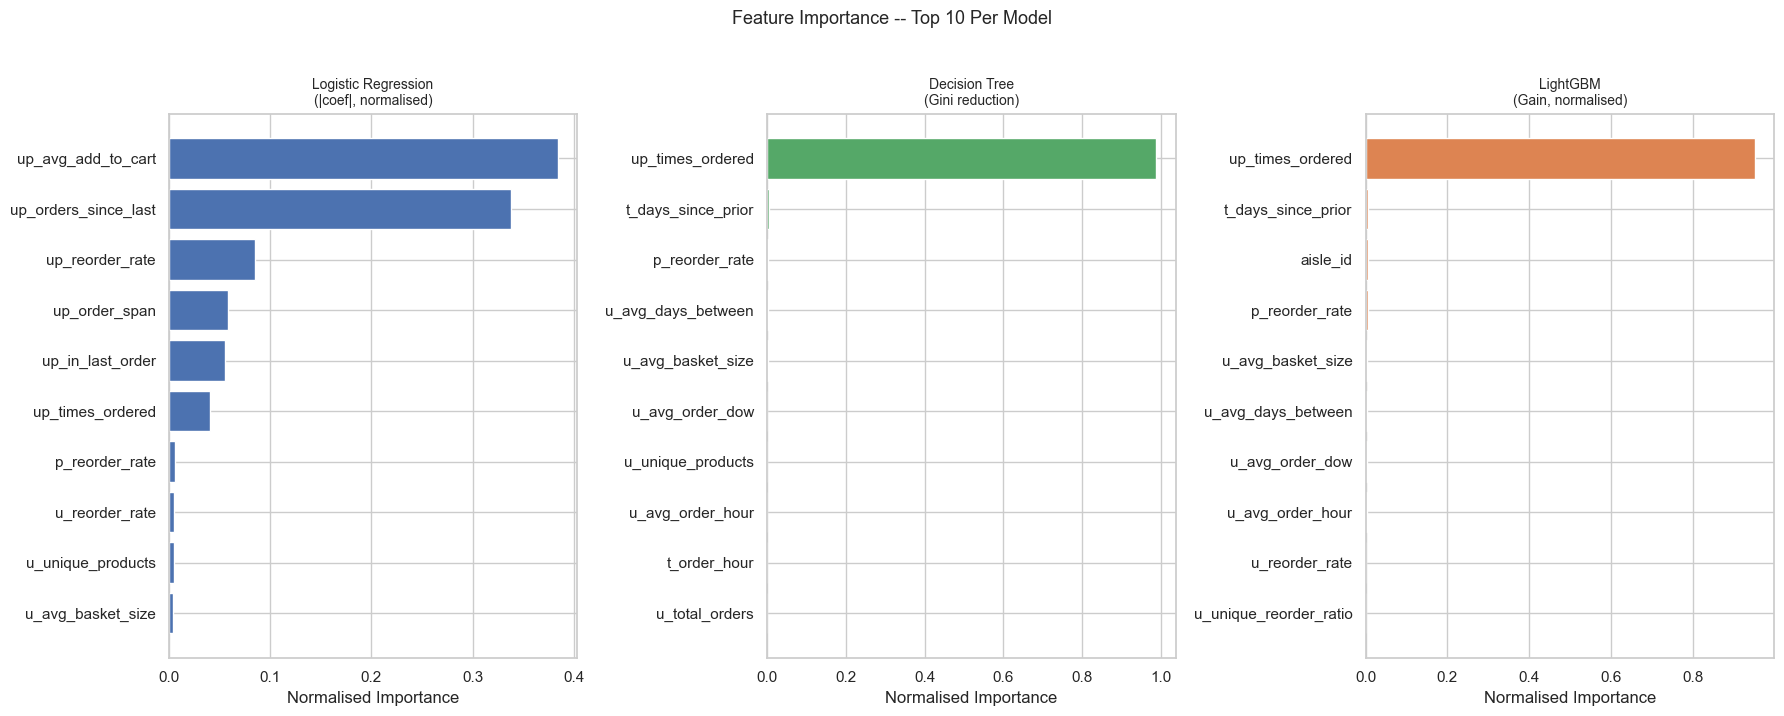

In [7]:
lr_imp = lr_coef_df[['feature', 'coefficient']].copy()
lr_imp['importance'] = lr_imp['coefficient'].abs()
lr_imp['importance'] = lr_imp['importance'] / lr_imp['importance'].sum()
lr_imp = lr_imp.sort_values('importance', ascending=False)

lgb_gain = lgb_imp_df.copy()
lgb_gain['importance_norm'] = lgb_gain['importance'] / lgb_gain['importance'].sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, imp_df, feat_col, imp_col, title, color in [
    (axes[0], lr_imp.head(10),    'feature', 'importance',      'Logistic Regression\n(|coef|, normalised)', COLORS['Logistic Regression']),
    (axes[1], dt_imp_df.head(10), 'feature', 'importance',      'Decision Tree\n(Gini reduction)',           COLORS['Decision Tree']),
    (axes[2], lgb_gain.head(10),  'feature', 'importance_norm', 'LightGBM\n(Gain, normalised)',              COLORS['LightGBM']),
]:
    ax.barh(imp_df[feat_col], imp_df[imp_col], color=color, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Normalised Importance')
    ax.invert_yaxis()

plt.suptitle('Feature Importance -- Top 10 Per Model', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 4.2 Feature Consistency Across Models

In [8]:
top_n = 10
lr_top  = set(lr_imp.head(top_n)['feature'].tolist())
dt_top  = set(dt_imp_df.head(top_n)['feature'].tolist())
lgb_top = set(lgb_gain.head(top_n)['feature'].tolist())

all_three    = lr_top & dt_top & lgb_top
two_of_three = ((lr_top & dt_top) | (lr_top & lgb_top) | (dt_top & lgb_top)) - all_three
only_one     = (lr_top | dt_top | lgb_top) - (lr_top & dt_top) - (lr_top & lgb_top) - (dt_top & lgb_top)

print('Features in TOP 10 across ALL three models (robust signal):')
for f in sorted(all_three):
    print(f'  {f}')

print('\nFeatures in TOP 10 in exactly TWO models:')
for f in sorted(two_of_three):
    in_models = []
    if f in lr_top:  in_models.append('LR')
    if f in dt_top:  in_models.append('DT')
    if f in lgb_top: in_models.append('LGB')
    print(f'  {f:<35} ({chr(44).join(in_models)})')

print('\nFeatures in TOP 10 in only ONE model (model-specific):')
for f in sorted(only_one):
    in_models = []
    if f in lr_top:  in_models.append('LR')
    if f in dt_top:  in_models.append('DT')
    if f in lgb_top: in_models.append('LGB')
    print(f'  {f:<35} ({chr(44).join(in_models)})')


Features in TOP 10 across ALL three models (robust signal):
  p_reorder_rate
  u_avg_basket_size
  up_times_ordered

Features in TOP 10 in exactly TWO models:
  t_days_since_prior                  (DT,LGB)
  u_avg_days_between                  (DT,LGB)
  u_avg_order_dow                     (DT,LGB)
  u_avg_order_hour                    (DT,LGB)
  u_reorder_rate                      (LR,LGB)
  u_unique_products                   (LR,DT)

Features in TOP 10 in only ONE model (model-specific):
  aisle_id                            (LGB)
  t_order_hour                        (DT)
  u_total_orders                      (DT)
  u_unique_reorder_ratio              (LGB)
  up_avg_add_to_cart                  (LR)
  up_in_last_order                    (LR)
  up_order_span                       (LR)
  up_orders_since_last                (LR)
  up_reorder_rate                     (LR)


## 5. Cost-Benefit Analysis

Each model offers a different set of tradeoffs across five dimensions: predictive performance, interpretability, training speed, calibration quality, and deployment simplicity.


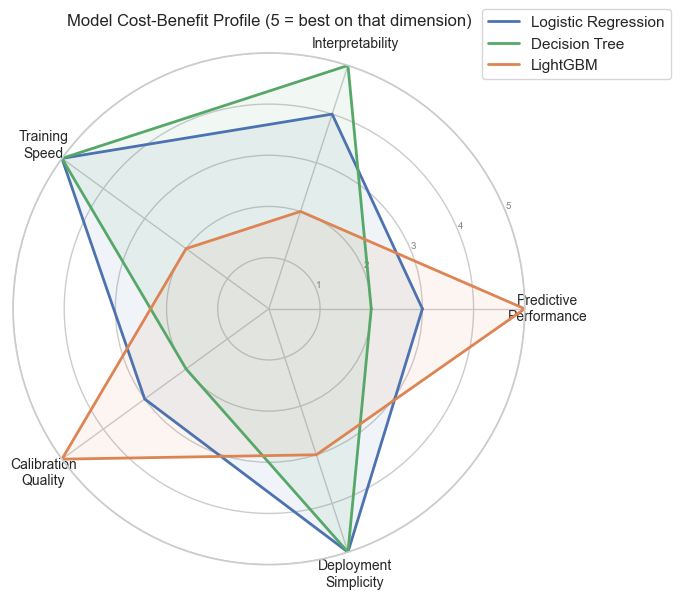

Scoring rationale (scale 1-5, 5=best):
  Predictive Performance : LGB=5, LR=3, DT=2  (based on ROC-AUC ranking)
  Interpretability       : DT=5 (flowchart), LR=4 (coefficients), LGB=2 (black box)
  Training Speed         : LR=DT=5 (seconds), LGB=2 (hours on this hardware)
  Calibration Quality    : LGB=5, DT=2, LR=3  (based on Brier Score ranking)
  Deployment Simplicity  : LR=DT=5 (single sklearn object), LGB=3 (categorical prep needed)


In [9]:
dims   = ['Predictive\nPerformance', 'Interpretability',
          'Training\nSpeed', 'Calibration\nQuality', 'Deployment\nSimplicity']
scores = {
    'Logistic Regression': [3, 4, 5, 3, 5],
    'Decision Tree'      : [2, 5, 5, 2, 5],
    'LightGBM'           : [5, 2, 2, 5, 3],
}

angles = np.linspace(0, 2*np.pi, len(dims), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for model, vals in scores.items():
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, color=COLORS[model], lw=2, label=model)
    ax.fill(angles, vals_plot, color=COLORS[model], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dims, fontsize=10)
ax.set_yticks([1,2,3,4,5])
ax.set_yticklabels(['1','2','3','4','5'], fontsize=7, color='grey')
ax.set_ylim(0, 5)
ax.set_title('Model Cost-Benefit Profile (5 = best on that dimension)',
             fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

print('Scoring rationale (scale 1-5, 5=best):')
print('  Predictive Performance : LGB=5, LR=3, DT=2  (based on ROC-AUC ranking)')
print('  Interpretability       : DT=5 (flowchart), LR=4 (coefficients), LGB=2 (black box)')
print('  Training Speed         : LR=DT=5 (seconds), LGB=2 (hours on this hardware)')
print('  Calibration Quality    : LGB=5, DT=2, LR=3  (based on Brier Score ranking)')
print('  Deployment Simplicity  : LR=DT=5 (single sklearn object), LGB=3 (categorical prep needed)')


### 5.1 Detailed Cost-Benefit Narrative

#### Logistic Regression
**Benefits:** Fastest to train (seconds), simplest to deploy, coefficients provide a direct linear explanation of predictions, well-understood by stakeholders at all technical levels.

**Costs:** Cannot capture non-linear relationships or feature interactions. Produced unstable coefficients for `up_avg_add_to_cart` and `up_orders_since_last` due to near-perfect linear separation on a subset of training data, requiring those features to be excluded.

**Best suited for:** Situations where explainability to non-technical stakeholders is the primary requirement, or where frequent retraining speed matters most.

---

#### Decision Tree
**Benefits:** The only model that produces a complete, human-readable decision flowchart -- every prediction traceable to an explicit sequence of if/else rules. Competitive with Logistic Regression on all metrics despite using 3 fewer features. No scaling required.

**Costs:** Probability outputs are discrete (one value per leaf) giving inherently worse calibration. Dominated by a single feature (`up_times_ordered` = 98.8% of Gini reduction), raising robustness questions if that feature distribution shifts.

**Best suited for:** Regulatory or audit contexts requiring fully explainable, auditable predictions -- or as an interpretability companion to LightGBM in production.

---

#### LightGBM
**Benefits:** Best performance on every metric. Native categorical handling extracts signal from `aisle_id` and `department_id` that the other models cannot access. Best probability calibration (Brier = 0.0458). Industry standard for tabular prediction.

**Costs:** Training took hours on available hardware. Black-box predictions. Requires libomp system dependency on macOS. Categorical dtype preparation at inference time.

**Best suited for:** Production deployment where predictive accuracy and probability calibration are the primary requirements.


## 6. Pending Issues Resolution

This section formally closes all issues flagged during Steps 1-6.


In [10]:
issues = [
    ('Step 4 -- Coefficient instability (up_avg_add_to_cart, up_orders_since_last)',
     'Option C applied: both features excluded from LR and DT feature sets.',
     'Step 6 gain importance confirmed neither appears in top 10. '
     'Exclusion appropriate -- insufficient marginal signal to justify full pipeline re-run.',
     'RESOLVED'),
    ('Steps 1-3 -- Data leakage in up_ features (v1 and v2)',
     'Correct fix applied in v3/v4: up_ features recomputed excluding the most recent prior order.',
     'Aggregation window was root cause, not individual columns. '
     'Confirmed by realistic metrics post-correction.',
     'RESOLVED'),
    ('Step 5 (DT) -- up_times_ordered dominance (98.8% of Gini reduction)',
     'Documented as a finding. No corrective action taken.',
     'Consistent across all three models -- reflects genuine data property. '
     'Purchase frequency is the strongest reorder predictor by a large margin.',
     'DOCUMENTED'),
    ('Step 5 (DT) -- Three features unused (p_total_purchases, up_reorder_rate, up_in_last_order)',
     'Documented. Features retained for pipeline consistency.',
     'With up_times_ordered dominating, correlated features are redundant for the tree.',
     'DOCUMENTED'),
    ('aisle_id -- excluded from LR and DT, included in LightGBM',
     'Confirmed correct decision.',
     'LightGBM ranked aisle_id 3rd by gain, validating native categorical treatment. '
     'Linear models correctly excluded it as non-ordinal and non-significant.',
     'CONFIRMED CORRECT'),
]

for issue, decision, rationale, status in issues:
    print(f'[{status}]')
    print(f'Issue    : {issue}')
    print(f'Decision : {decision}')
    print(f'Rationale: {rationale}')
    print()


[RESOLVED]
Issue    : Step 4 -- Coefficient instability (up_avg_add_to_cart, up_orders_since_last)
Decision : Option C applied: both features excluded from LR and DT feature sets.
Rationale: Step 6 gain importance confirmed neither appears in top 10. Exclusion appropriate -- insufficient marginal signal to justify full pipeline re-run.

[RESOLVED]
Issue    : Steps 1-3 -- Data leakage in up_ features (v1 and v2)
Decision : Correct fix applied in v3/v4: up_ features recomputed excluding the most recent prior order.
Rationale: Aggregation window was root cause, not individual columns. Confirmed by realistic metrics post-correction.

[DOCUMENTED]
Issue    : Step 5 (DT) -- up_times_ordered dominance (98.8% of Gini reduction)
Decision : Documented as a finding. No corrective action taken.
Rationale: Consistent across all three models -- reflects genuine data property. Purchase frequency is the strongest reorder predictor by a large margin.

[DOCUMENTED]
Issue    : Step 5 (DT) -- Three featur

## 7. Final Model Recommendation

In [11]:
rec = [
    'FINAL MODEL RECOMMENDATION',
    '=' * 50,
    'RECOMMENDED FOR DEPLOYMENT: LightGBM',
    '',
    f'  ROC-AUC : 0.9710  (+0.0021 vs LR, +0.0025 vs DT)',
    f'  PR-AUC  : 0.9851  (+0.0010 vs LR, +0.0017 vs DT)',
    f'  Brier   : 0.0458  (-0.0014 vs LR, -0.0008 vs DT)',
    f'  F1      : 0.9533  (+0.0013 vs LR, +0.0003 vs DT)',
    '=' * 50,
]
print('\n'.join(rec))


FINAL MODEL RECOMMENDATION
RECOMMENDED FOR DEPLOYMENT: LightGBM

  ROC-AUC : 0.9710  (+0.0021 vs LR, +0.0025 vs DT)
  PR-AUC  : 0.9851  (+0.0010 vs LR, +0.0017 vs DT)
  Brier   : 0.0458  (-0.0014 vs LR, -0.0008 vs DT)
  F1      : 0.9533  (+0.0013 vs LR, +0.0003 vs DT)


### Recommendation Rationale

**LightGBM is the recommended model for deployment** based on the following:

**1. Best performance on every metric without exception.** LightGBM leads both alternatives on ROC-AUC, PR-AUC, Brier Score, and F1 simultaneously. At >0.96 AUC, every incremental gain is hard-won -- a +0.0021 improvement across 277,201 test cases represents thousands of correctly reclassified predictions.

**2. Best probability calibration.** Brier Score of 0.0458 confirms LightGBM produces the most accurately calibrated probabilities. In a reorder prediction context, calibration matters: a score of 0.85 should mean the product is reordered 85% of the time, enabling reliable threshold selection and downstream business logic.

**3. Native categorical handling.** LightGBM correctly treats `aisle_id` and `department_id` as unordered groups, extracting genuine predictive signal (aisle_id ranked 3rd by gain) that Logistic Regression and Decision Tree cannot access.

**4. Consistent dominance across all metrics.** Small margins (+0.002 AUC) that are consistent across every evaluation approach are more meaningful than a large lead on one metric with deficits elsewhere.

---

### When to consider the alternatives

**Choose Logistic Regression if:** Retraining frequency is a constraint, or the deployment environment does not support LightGBM dependencies.

**Choose Decision Tree if:** A regulatory or audit requirement demands a fully explainable, human-readable model where every prediction can be traced to explicit rules.

**Consider using Decision Tree as a companion to LightGBM:** In production, LightGBM handles scoring while the Decision Tree serves as an interpretability layer -- a simplified shadow model that approximates LightGBM behaviour and can explain individual predictions to non-technical stakeholders.

---

### What Step 8 covers
Step 8 implements the full LightGBM deployment pipeline:
- **Part 1 (current):** Prediction function taking raw user/product features,   returning reorder probability with example demonstrations
- **Part 2:** Batch scoring pipeline ranking all products for a given user
- **Part 3:** REST API wrapper (Flask) enabling external calls


In [12]:
summary = pd.DataFrame({
    'Model'      : ['Logistic Regression', 'Decision Tree', 'LightGBM'],
    'ROC-AUC'    : [0.9689, 0.9685, 0.9710],
    'PR-AUC'     : [0.9841, 0.9834, 0.9851],
    'Brier'      : [0.0472, 0.0466, 0.0458],
    'F1'         : [0.9520, 0.9530, 0.9533],
    'Recommended': ['No', 'No', 'YES'],
})

summary.to_csv(os.path.join(MODEL_DIR, 'model_comparison.csv'), index=False)
print(f'Model comparison saved to: {os.path.abspath(MODEL_DIR)}/model_comparison.csv')
print()
print(summary.to_string(index=False))


Model comparison saved to: /Users/martinmilon/Documents/DTSC870/models/model_comparison.csv

              Model  ROC-AUC  PR-AUC  Brier     F1 Recommended
Logistic Regression   0.9689  0.9841 0.0472 0.9520          No
      Decision Tree   0.9685  0.9834 0.0466 0.9530          No
           LightGBM   0.9710  0.9851 0.0458 0.9533         YES
